# Exploratory Data Analysis of EuRepoC Reported Cyber Incidents 
Using the the latent topics extracted from incident descriptions (see build_BERTopic_model.ipynb), are specific types of cyber attacks linked to differences in terms of societal impact and political responses? 

Q1: What operational patterns connect initiator countries, cyber operation types, and receiver countries?

Q2: Which operational categories are associated with the most severe incidents?

Q3: What types of cyber operations provoke political responses?

Q4: How have trends in cyber operations evolved over time?

Q5: Which countries are targeted by which types of cyber operations?

Q6: Are there patterns in the types of cyber attacks used by initiator countries?

**Variable codes:** 

impact_indicator_score = economic impact + political impact + intelligence impact + functional impact 
- 1 = Minor
- 2 = Low
- 3 = Medium
- 4 = High
- 5 = Very High

topic_names = latent cyber operation types extracted from topic modeling (BERTopic)
- Website Defacement & Hacktivism (topic label = 0)
- Malware & Cyber Espionage (topic label = 1)
- Ransomware & Cyber Extortion (topic label = 2)
- DDoS & Service Disruption Campaigns (topic label = 3)
- Data Breaches & Information Exposure (topic label = 4)
- Instiutional Ransomware Attacks (topic label = 5)
- Vulnerability Exploitation & Theft (topic label = 6)
- Surveillance & Mobile Espionage (topic label = 7)
- Government Intelligence Operations (topic label = 8)

topic_groups = condensed clusters based on topic names
- Hacktivism = Website Defacement & Hacktivism
- Disruption Operations = DDoS & Service Disruption Campaigns
- Intrusion = Malware & Cyber Espionage, Vulnerability Exploitation & Theft
- Information = Surveillance & Mobile Espionage, Government Intelligence Operations
- Data Exposure = Data Breaches & Information Exposure
- Financially Motivated Operations = Ransomware & Cyber Extortion, Institutional Ransomware Attacks


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
from src.nlp_functions import(remove_geo_entities,
                              _mps_override)
from scipy.stats import kruskal
import scikit_posthocs as sp
from bertopic import BERTopic
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

/Users/heather.iriye/Library/CloudStorage/OneDrive-KarolinskaInstitutet/Documents/GitHub/eurepoc_cyber_security-/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Only run this block if in codespaces
# Register the override handler in torch's deserialization registry (built on Mac, running in Codespaces)
torch.serialization._package_registry.insert(0, (lambda loc: loc.startswith("mps"), "mps", _mps_override))

In [ ]:
# Load pre-saved model & data 
topic_model = BERTopic.load(
    "data/topic_model/eurepoc_final_model"
)

topic_assignments = pd.read_csv(
    "data/topic_model/eurepoc_topic_assignments.csv"
)

topic_info = pd.read_csv(
    "data/topic_model/topic_info.csv"
)

dyadic_data = pd.read_csv(
    "data/eurepoc_dataset/dyadic_data_topics.csv"
)

### Q1: What operational patterns connect initiator countries, cyber operation types, and receiver countries?

In [3]:
# Filters for sankey visual
top_initiators = (
    dyadic_data["initiator_country"]
    .value_counts()
    .head(10)
    .index
)

top_receivers = (
    dyadic_data["receiver_country"]
    .value_counts()
    .head(10)
    .index
)

sankey_data = dyadic_data[
    dyadic_data["initiator_country"].isin(top_initiators)
    &
    dyadic_data["receiver_country"].isin(top_receivers)
].copy()

In [4]:
# Shorten topic labels
sankey_data["short_topic"] = (
    sankey_data["topic_group"]
    .str.split(",")
    .str[:3]
    .str.join(", ")
)

In [5]:
# Create flows
# Initiator -> Topic
flow1 = (
    sankey_data
    .groupby(
        ["initiator_country", "short_topic"]
    )
    .size()
    .reset_index(name="value")
)

# Topic -> Reciever
flow2 = (
    sankey_data
    .groupby(
        ["short_topic", "receiver_country"]
    )
    .size()
    .reset_index(name="value")
)

In [6]:
# Build node list
nodes = list(
    pd.concat([
        flow1["initiator_country"],
        flow1["short_topic"],
        flow2["receiver_country"]
    ]).unique()
)

node_dict = {
    node: i
    for i, node in enumerate(nodes)
}

In [7]:
# Build link table
source = []
target = []
value = []

# Initiator -> Topic
for _, row in flow1.iterrows():
    source.append(
        node_dict[row["initiator_country"]]
    )
    target.append(
        node_dict[row["short_topic"]]
    )
    value.append(row["value"])

# Topic -> Receiver
for _, row in flow2.iterrows():
    source.append(
        node_dict[row["short_topic"]]
    )
    target.append(
        node_dict[row["receiver_country"]]
    )
    value.append(row["value"])

In [22]:
fig = go.Figure(
    go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            label=nodes
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title="Cyber Conflict Flows: Initiator → Topic → Receiver",
    font_size=10
)

fig.write_html("visualizations/cyber_conflict_sankey.html")

fig.show()


The Sankey plot visualizes the flow of cyber incidents from initiating actors to operational categories and finally to recipient countries. The width of each flow is proportional to the number of incidents observed in the dataset. Cyber incidents are first grouped by initiator country, then aggregated into five broad operational categories derived from BERTopic analysis: **hacktivism, disruption operations, intrusion operations, information operations, data exposure, and financially motivated operations**. The final stage shows the principal recipient countries associated with each operational category. 

**Key Findings**
1. **Financially motivated operations constitute the largest category of incidents**, indicating that ransomware and extortion-related activities are among the most prevalent forms of cyber conflict represented in the dataset.
2. **Attribution remains a major challenge in cyber conflict**, as "Not Attributed" and "Unknown" represent some of the largest initiating categories in the diagram.
3. **The US is the largest recipient node**, receiving substantial flows across multiple operational categories, particularily financially motivated operations, intrusion operations, data exposure, and disruption operations. 
4. **Intrusion opeerations are strongly linked with state-linked actors**. China, Russia, and several other state actors are connected to malware operations, cyber espionage, and vulnerabilty exploitation. The pattern is consistent with the use of cyber capabilities for intelligence collection and network penetration. 

# Q2: Which operational categories are associated with the most impactful incidents?

In [9]:
topic_summary = (
    dyadic_data
    .groupby("topic_group")
    .agg(
        incidents=("incident_id", "count"),
        avg_impact_score=("impact_indicator_score", "mean"),
        avg_intensity=("weighted_intensity", "mean"),
        avg_political=("number_political_responses", "mean"),
        avg_legal=("number_legal_responses", "mean")
    )
    .round(2)
)

print(topic_summary)

                                  incidents  avg_impact_score  avg_intensity  \
topic_group                                                                    
Data Exposure                           194              6.15           3.12   
Disruption Operations                   202              4.49           1.16   
Financially Motivated Operations        422              6.79           3.60   
Hacktivism                              478              0.52           1.41   
Information Operations                  127              1.95           3.03   
Intrusion Operations                    823              3.48           2.52   

                                  avg_political  avg_legal  
topic_group                                                 
Data Exposure                              0.12       0.35  
Disruption Operations                      0.28       0.11  
Financially Motivated Operations           0.12       0.37  
Hacktivism                                 0.01       

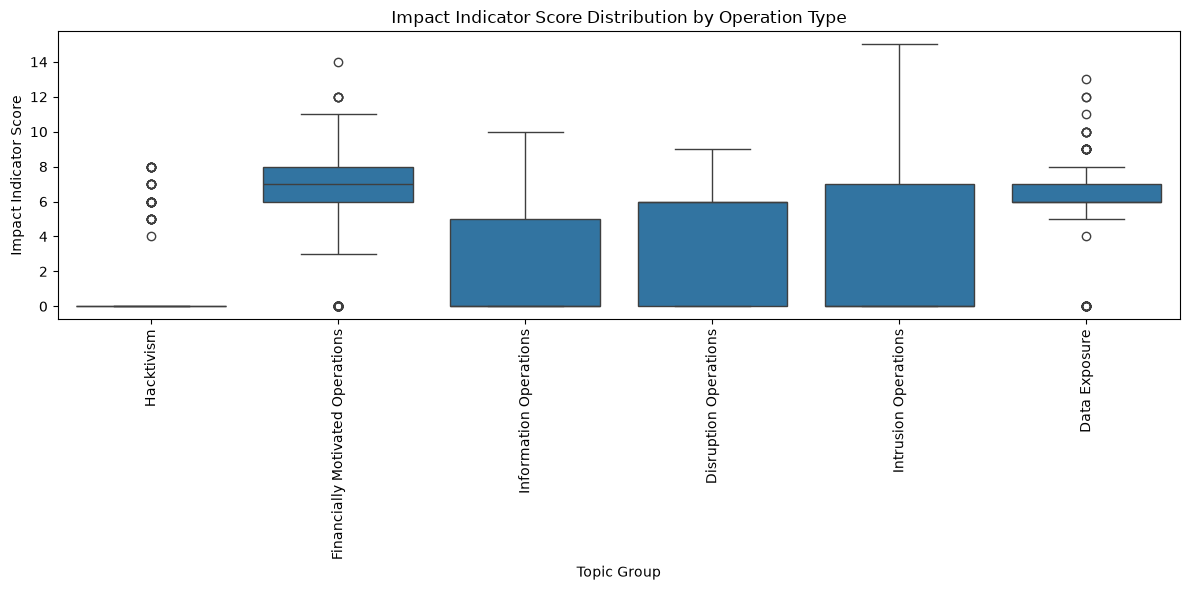

In [21]:
# Impact indicator score x topic group boxplot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=dyadic_data,
    x="topic_group",
    y="impact_indicator_score"
)

plt.xticks(rotation=90)
plt.ylabel("Impact Indicator Score")
plt.xlabel("Topic Group")
plt.title("Impact Indicator Score Distribution by Operation Type")

# save figure
plt.tight_layout()
plt.savefig(
    "visualizations/impact_indicator_score_by_topic_group_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [11]:
# First drop duplicate incident_ids in the dataset
topic_analysis = (
    dyadic_data
    .drop_duplicates(subset=["incident_id"])
    .copy()
)

# Check sample sizes
print(
    dyadic_data.groupby("topic_group")
    .size()
    .sort_values(ascending=False)
)

# Run Kruskal-Wallis test
groups = [
    g["impact_indicator_score"].dropna()
    for _, g in topic_analysis.groupby("topic_group")
]

stat, p = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.3f}")
print(f"p-value: {p:.6f}")

alpha = 0.05

if p < alpha:
    print("Significant differences in weighted intensity across latent topic groups.")
else:
    print("No significant differences in weighted intensity across latent topic groups.")


topic_group
Intrusion Operations                823
Hacktivism                          478
Financially Motivated Operations    422
Disruption Operations               202
Data Exposure                       194
Information Operations              127
dtype: int64
Kruskal-Wallis H-statistic: 690.907
p-value: 0.000000
Significant differences in weighted intensity across latent topic groups.


In [12]:
# Dunn test
dunn = sp.posthoc_dunn(
    topic_analysis,
    val_col="impact_indicator_score",
    group_col="topic_group",
    p_adjust="bonferroni"
)


# Convert Dunn matrix to long format
results = []

for i, row in enumerate(dunn.index):
    for j, col in enumerate(dunn.columns):

        # Keep upper triangle only
        if i < j:

            p = dunn.loc[row, col]

            results.append({
                "Comparison": f"{row} vs {col}",
                "p-value": p,
                "Significant": "Yes" if p < 0.05 else "No"
            })

dunn_table = pd.DataFrame(results)

dunn_table = (
    dunn_table
    .sort_values("Comparison")
    .reset_index(drop=True)
)

dunn_table["p-value"] = (
    dunn_table["p-value"]
    .apply(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}")
)

print(dunn_table.to_string(index=False))

                                                Comparison p-value Significant
                    Data Exposure vs Disruption Operations  <0.001         Yes
         Data Exposure vs Financially Motivated Operations   0.328          No
                               Data Exposure vs Hacktivism  <0.001         Yes
                   Data Exposure vs Information Operations  <0.001         Yes
                     Data Exposure vs Intrusion Operations  <0.001         Yes
 Disruption Operations vs Financially Motivated Operations  <0.001         Yes
                       Disruption Operations vs Hacktivism  <0.001         Yes
           Disruption Operations vs Information Operations   0.267          No
             Disruption Operations vs Intrusion Operations   0.011         Yes
            Financially Motivated Operations vs Hacktivism  <0.001         Yes
Financially Motivated Operations vs Information Operations  <0.001         Yes
  Financially Motivated Operations vs Intrusion Oper

## Key Findings

**1. Operational type is associated with severity**
- The Kruskal-Wallis test found significant variation in incident intensity between most categories
- The way a cyber operation is conducted appears to be linked ot its observed societal impact, with ransomware and extortion representing the most distinct category and hacktivist activities generally representing the least severe

**2. Data exposure and financially motivated operations have the largest societal impacts (combination of economic, political, intelligence, and functional effects)**
- Data breaches, ransomware, and cyber extortion are linked to the highest impact scores and display similar profiles

**3. Hacktivism/website defacement occupies the lower-intensity end of the spectrum, but watch for the outliers**
- Website defacements have significantly lower impact scores than all other groups
- But there several cases with unusually high impact scores identified in the boxplot

**4. Disruption operations and information operations show similar impact severity profiles**
- Surveillance, espionage, government intelligence operations, and DDoS campaigns have roughly equal impact scores
- However, it is not clear from this analysis whether they affect different sectors of society in the same way (i.e., economic, political, intelligence, or functional impacts).

**5. Information and intrusion operations are also similar in terms of societal impact**
- Surveillance, espionage, government intelligence operations, malware, vulnerability exploitation and theft have similar impact scores


## Q3: What types of cyber operations provoke political reactions?

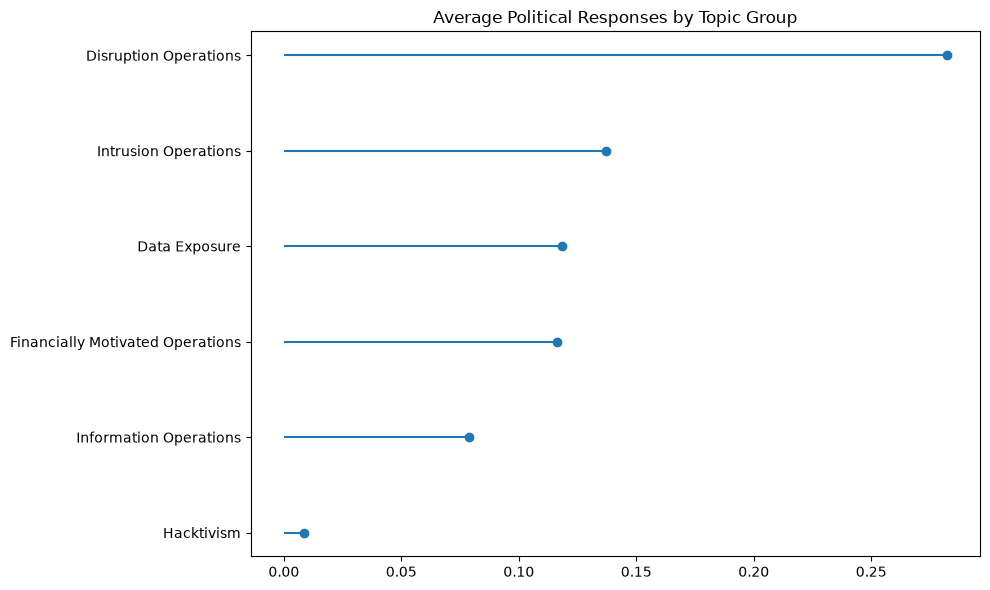

In [23]:
responses = (
    dyadic_data.groupby("topic_group")
    ["number_political_responses"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.hlines(
    y=responses.index,
    xmin=0,
    xmax=responses.values
)

plt.plot(
    responses.values,
    responses.index,
    "o"
)

plt.title("Average Political Responses by Topic Group")

# save figure
plt.tight_layout()
plt.savefig(
    "visualizations/political_responses_by_topic_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

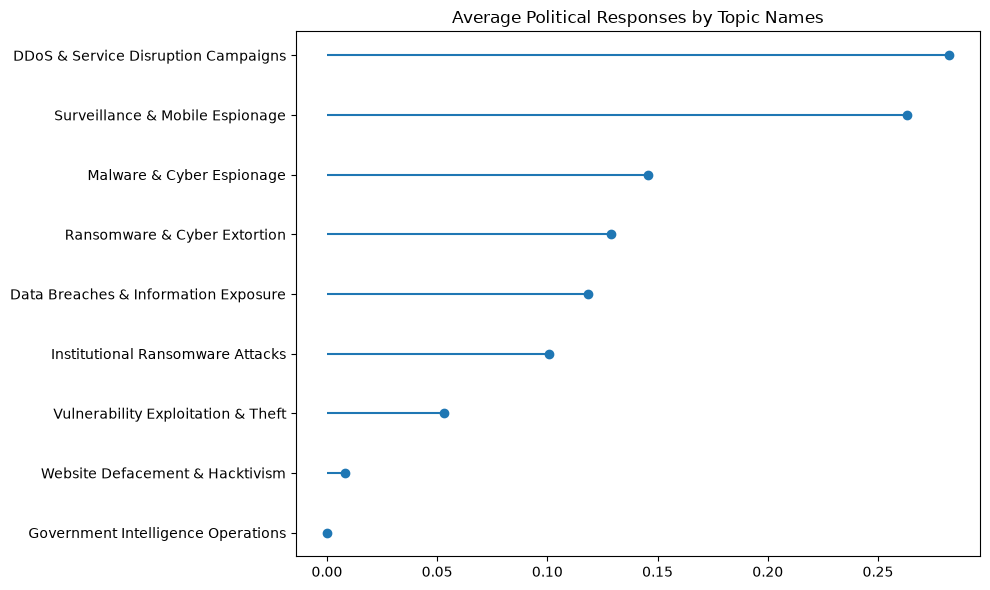

In [24]:
responses = (
    dyadic_data.groupby("topic_name")
    ["number_political_responses"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.hlines(
    y=responses.index,
    xmin=0,
    xmax=responses.values
)

plt.plot(
    responses.values,
    responses.index,
    "o"
)

plt.title("Average Political Responses by Topic Names")

# save figure
plt.tight_layout()
plt.savefig(
    "visualizations/political_responses_by_topic_names.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Findings:

1. Disruption operations (DDoS and service disruption campaigns) trigger the biggest politic reactions
2. Surviellance and mobile espionage tend to trigger relatively high political reactions, but government intelligence operations trigger none. Noteworthy as both topics are combined under larger "Information Operations" group. 
3. Hacktivism and website defacement are linked with low political responses.
4. Intrusion operations, data exposure, and financially motivated operations occupy the middle of the spectrum. 

## Q4: How have trends in cyber operations evolved over time? 
a) Which types of cyber operations are on the rise/decline?

b) Are cyber operations leading to greater societal impacts over time?

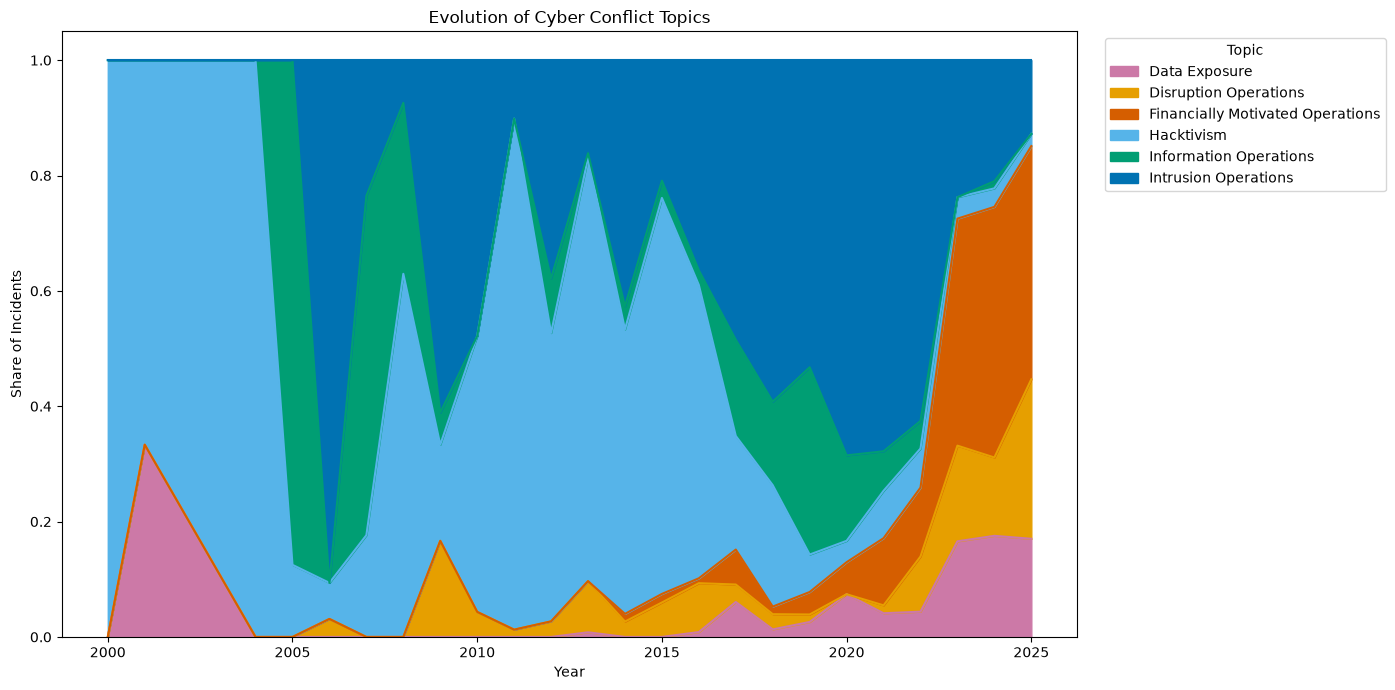

In [25]:
# Extract year from incident date
dyadic_data["year"] = pd.to_datetime(
    dyadic_data["start_date"],
    errors="coerce"  # invalid dates become NaT
).dt.year

# Calculate annual topic shares
topic_year = pd.crosstab(
    dyadic_data["year"],
    dyadic_data["topic_group"],
    normalize="index"
)

# Consistent color scheme
topic_colors = {
    "Financially Motivated Operations": "#D55E00",  # orange-red
    "Intrusion Operations": "#0072B2",             # blue
    "Data Exposure": "#CC79A7",                    # purple
    "Information Operations": "#009E73",          # green
    "Disruption Operations": "#E69F00",           # amber
    "Hacktivism": "#56B4E9",                      # light blue
}

colors = [
    topic_colors[col]
    for col in topic_year.columns
]

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

topic_year.plot.area(
    ax=ax,
    color=colors
)

ax.set_title("Evolution of Cyber Conflict Topics")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Incidents")

# Move legend outside plot
ax.legend(
    title="Topic",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

# Leave space for legend
plt.tight_layout(rect=[0, 0, 0.8, 1])

# save figure
plt.tight_layout()
plt.savefig(
    "visualizations/evolution_of_cyber_conflict_topics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# Trend analysis by topic
annual_topic_share = (
    pd.crosstab(
        dyadic_data["year"],
        dyadic_data["topic_group"],
        normalize="index"
    )
)

results = []

for topic in annual_topic_share.columns:

    rho, p = spearmanr(
        annual_topic_share.index,
        annual_topic_share[topic]
    )

    results.append([topic, rho, p])

trend_results = pd.DataFrame(
    results,
    columns=["Topic", "Spearman_rho", "p_value"]
)

# Holm correction
trend_results["p_adj"] = multipletests(
    trend_results["p_value"],
    method="holm"
)[1]

trend_results["Significant"] = (
    trend_results["p_adj"] < 0.05
)

trend_results.sort_values("p_adj")


,Topic,Spearman_rho,p_value,p_adj,Significant
2,Financially Motivated Operations,0.919965,2.046776e-10,1.228066e-09,True
0,Data Exposure,0.668601,3.549452e-04,1.774726e-03,True
3,Hacktivism,-0.641879,7.218258e-04,2.887303e-03,True
1,Disruption Operations,0.591594,2.327471e-03,6.982414e-03,True
5,Intrusion Operations,0.457517,2.457981e-02,4.915961e-02,True
4,Information Operations,0.103649,6.298264e-01,6.298264e-01,False


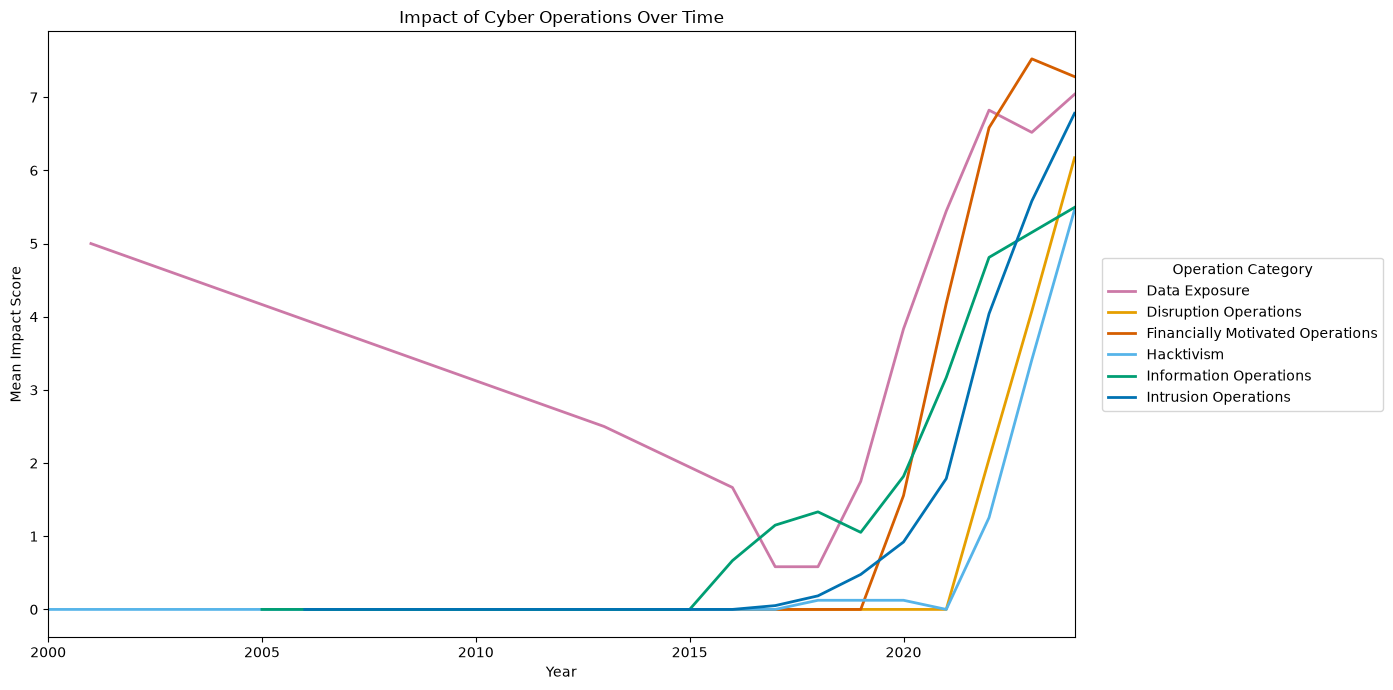

In [26]:
# Keep years through 2024 only
impact_by_group = (
    dyadic_data.loc[
        dyadic_data["year"] <= 2024
    ]
    .groupby(["year", "topic_group"])["impact_indicator_score"]
    .mean()
    .reset_index()
    .sort_values(["topic_group", "year"])
)

# Smooth lines
impact_by_group["impact_smoothed"] = (
    impact_by_group
    .groupby("topic_group")["impact_indicator_score"]
    .transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=impact_by_group,
    x="year",
    y="impact_smoothed",
    hue="topic_group",
    palette=topic_colors,
    linewidth=2,
    ax=ax
)

ax.set_title("Impact of Cyber Operations Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Impact Score")

# Ensure the axis stops at 2024
ax.set_xlim(
    impact_by_group["year"].min(),
    2024
)

# Legend outside plot
ax.legend(
    title="Operation Category",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

fig.subplots_adjust(right=0.75)

# save figure
plt.tight_layout()
plt.savefig(
    "visualizations/cyber_operation_impact_intensity_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [18]:
results = []

for group in dyadic_data["topic_group"].dropna().unique():

    group_data = (
        dyadic_data.loc[
            dyadic_data["topic_group"] == group
        ]
        .groupby("year")["impact_indicator_score"]
        .mean()
        .reset_index()
    )

    rho, p = spearmanr(
        group_data["year"],
        group_data["impact_indicator_score"]
    )

    results.append({
        "Topic Group": group,
        "Spearman rho": rho,
        "p-value": p
    })

trend_results = pd.DataFrame(results)

trend_results = (
    trend_results
    .sort_values("p-value")
    .reset_index(drop=True)
)

trend_results["p_adj"] = multipletests(
    trend_results["p-value"],
    method="holm"
)[1]

trend_results["Significant"] = (
    trend_results["p_adj"] < 0.05
)

print(
    trend_results
    .sort_values("p_adj")
    .round(3)
)

                        Topic Group  Spearman rho  p-value  p_adj  Significant
0            Information Operations         0.905    0.000  0.000         True
1              Intrusion Operations         0.745    0.000  0.001         True
2                        Hacktivism         0.542    0.006  0.025         True
3             Disruption Operations         0.567    0.018  0.053        False
4  Financially Motivated Operations         0.593    0.042  0.085        False
5                     Data Exposure         0.356    0.256  0.256        False


## Key Findings

1. There has been a sharp uptick in the number of financialy motivated operations in recent years
2. Data exposure and disruption operations have also been on the rise
3. Intrusion operations have increased since 2000 but have slowed in the last couple of years
4. The number of hacktivism incidents / website defacements have reduced since 2000
5. The number of information operations have not changed over time
6. Information operations, intrusion operations, and hacktivism incidents have become more severe in recent years.

## Q5: Are certain countries targeted by specific types of cyber operations? 

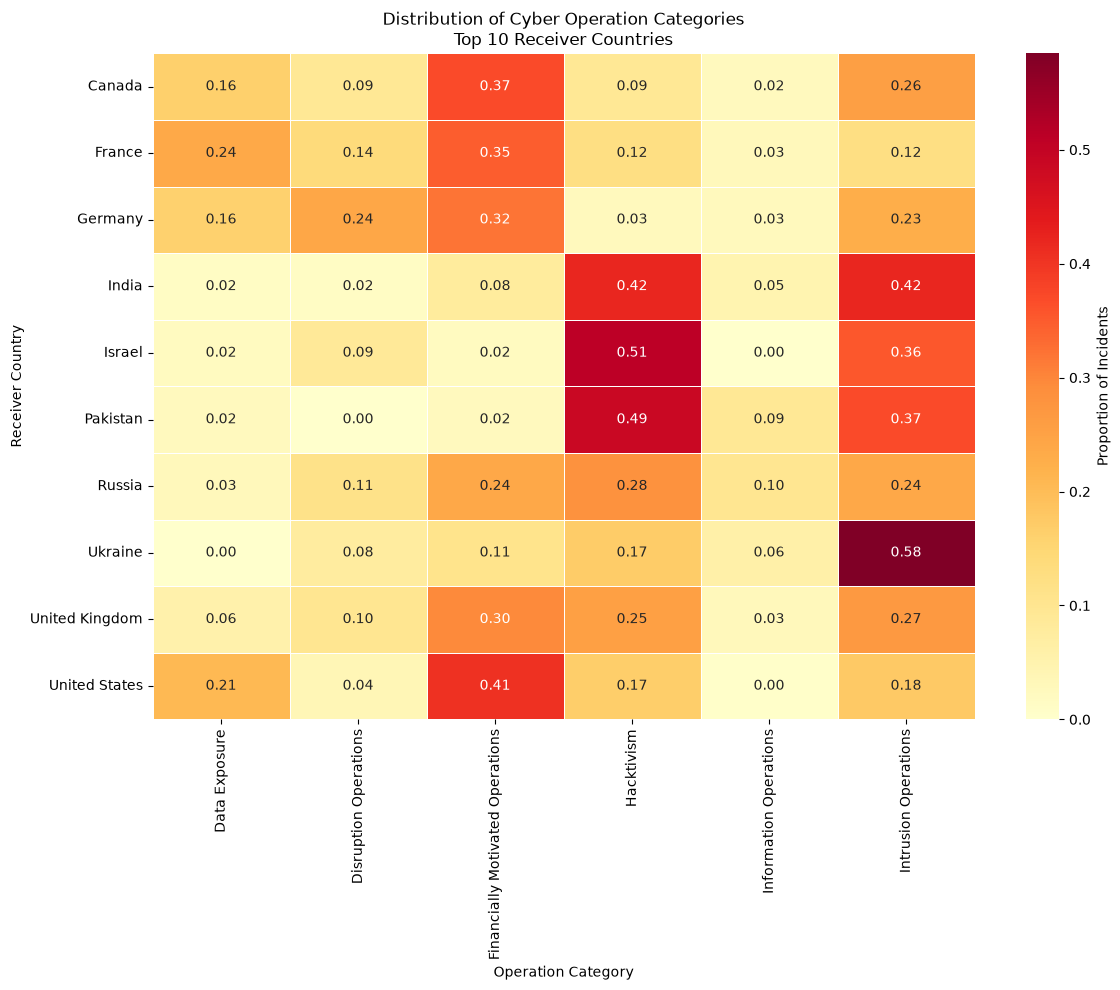

In [27]:
# Top 10 receiver countries by incident count
top_receivers = (
    dyadic_data["receiver_country"]
    .value_counts()
    .head(10)
    .index
)

# Normalized heatmap data
country_topic = pd.crosstab(
    dyadic_data.loc[
        dyadic_data["receiver_country"].isin(top_receivers),
        "receiver_country"
    ],
    dyadic_data.loc[
        dyadic_data["receiver_country"].isin(top_receivers),
        "topic_group"
    ],
    normalize="index"
)

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    country_topic,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={
        "label": "Proportion of Incidents"
    }
)

plt.title(
    "Distribution of Cyber Operation Categories\nTop 10 Receiver Countries"
)
plt.xlabel("Operation Category")
plt.ylabel("Receiver Country")

# save figure
plt.tight_layout()
plt.savefig(
    "visualizations/top_10_receiver_countries_operation_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Findings
**1. Financially motivated operations dominate Western countries**
- US (41%), Canada (37%), France (35%), Germany (32%), and the UK (30%) exhibit high proportions of ransomware and cyber extortion attacks

**2. Intrusion operations are concentrated in countries facing geopolitical tensions**
- Ukrain displays the highest proportion of intrusion operations (58%), far exceeding any other country
- India (42%), Pakistan (37%), and Israel (36%) also experience relatively highly levels
- Suggest a stronger presence of network compromise, malware, and exploitation campaigns in countries exposed to strategic or geopolitical competition

**3. Hacktivism is particularily prominent in Israel and Pakistan**
- Israel (51%) and Pakistan (49%) are most affected by symbolic cyber operations and politically motivated attacks, other countries have much lower proportions (even UK is only at 25%)


## Q6: Are there patterns in the types of cyber attacks used by initiator countries?

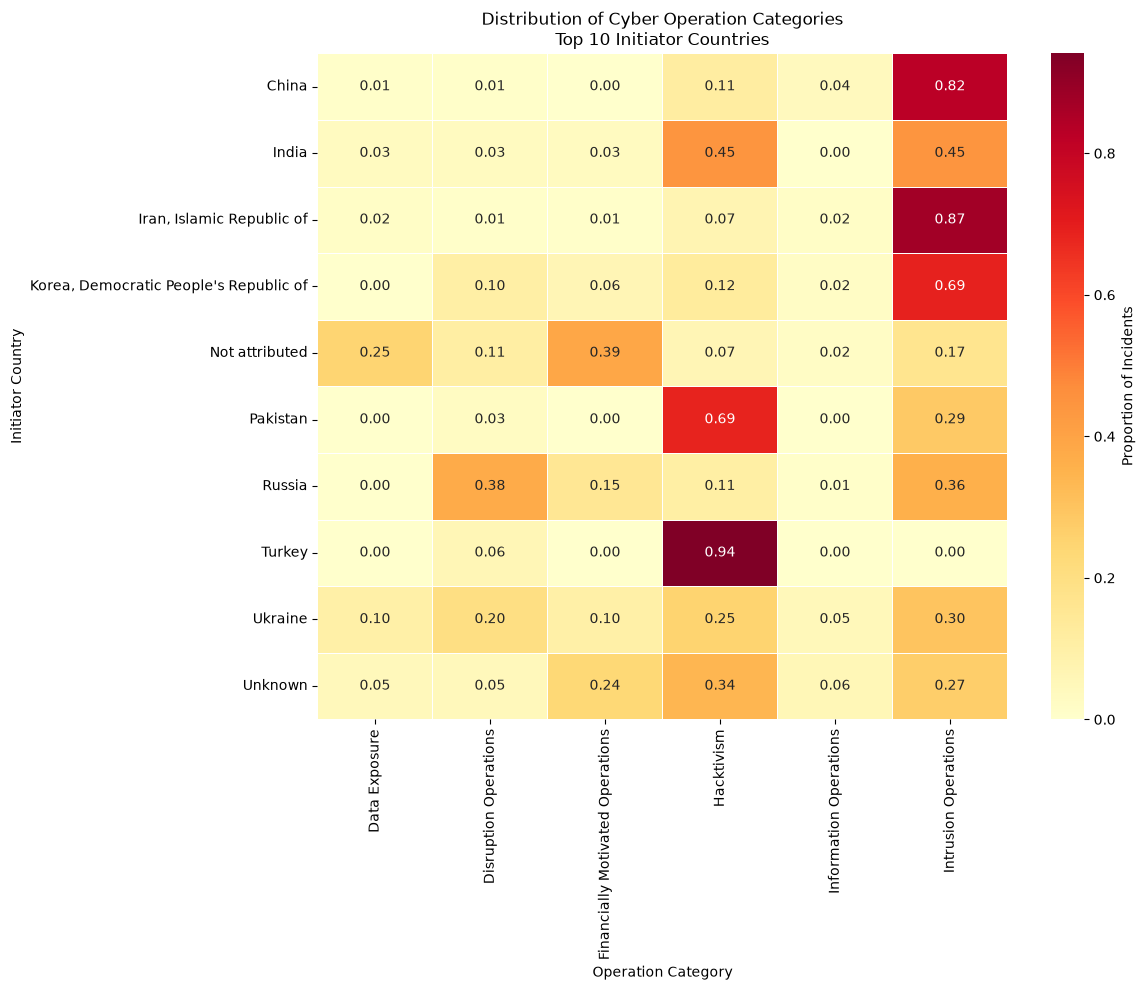

In [28]:
# Top 10 initiator countries by incident count
top_initiators = (
    dyadic_data["initiator_country"]
    .value_counts()
    .head(10)
    .index
)

# Normalized heatmap data
country_topic = pd.crosstab(
    dyadic_data.loc[
        dyadic_data["initiator_country"].isin(top_initiators),
        "initiator_country"
    ],
    dyadic_data.loc[
        dyadic_data["initiator_country"].isin(top_initiators),
        "topic_group"
    ],
    normalize="index"
)

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    country_topic,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={
        "label": "Proportion of Incidents"
    }
)

plt.title(
    "Distribution of Cyber Operation Categories\nTop 10 Initiator Countries"
)
plt.xlabel("Operation Category")
plt.ylabel("Initiator Country")

# save figure
plt.tight_layout()
plt.savefig(
    "visualizations/top_10_initiator_countries_operation_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Findings

**1. China, Iran, and North Korea initiate a high proportion of intrusion operations**
- Iran (87%), China (82%), and North Korea (69%) deploy malware attacks, network compromise operations, and cyber espionage at a high rate

**2. Hacktivism is concentrated among Turkey and Pakistan**
- Turkey (94%) is overwhelmingly associated with hacktivism, making it the most specialized actor in the dataset
- Pakistan (69%) also shows a strong concentration of hacktivist activity

**3. Russia displays the most balanced profile**
- Disruption operations (38%), intrusion operations (36%), financially motivated operations (15%) = broader operational repertoire

**4. Ukraine also exhibits a diverse mix of operations**
- Intrusion operations (30%), hacktivism (25%), and disruption operations (20%)
- Ukraine is one of the least specialized actors in the dataset

**5. Unattributed actors are strongly associated with financially motivated activity**
- Ransomware, extortion, and data theft frequently occur without reliable attribution 

# General Summary

Cyber conflict is increasingly shaped by **financially motivated activity**, while **state-linked intrusion operations** remain a persistent feature of geopolitical competition. Ransomware and data breaches create the greatest overall societal harm, disruption operations provoke the strongest political reactions, and intrusion campaigns are concentrated among states involved in strategic rivalries.

**1. Cyber conflict is increasingly dominated by cybercrime rather than purely state activity**

Financially motivated operations (ransomware, extortion) are the most common form of cyber incident in the dataset. Their rapid growth in recent years combined with high societal impact, suggests that financially driven actors now represent one of the most significant sources of cyber risk.

**2. Attribution remains one of the biggest challenges in cyberspace**

A large proportion of incidents are from "Unknown" or "Not Attributed" actors, particularily for financially motivated attacks. This highlights the difficulty in identifying perpetrators and holding them accountable.

**3. The US is the central target of cyber operations**

US recieves the largest volume of incidents across multiple operational categories, reflecting its geopolitical importance and attractiveness as a target for cybercriminal and state actors alike. 

**4. State actors primarily rely on intrusion and espionage operations**

China, Iran, North Korea, and Russia are strongly linked with malware, vulnerability exploitation, and cyber espionage. These operations appear focused on intelligence collection, strategic access, and long term network penetration rather than immediate disruption. 

**5. Different cyber operation types produce different levels of societal harm***

Highest impact: data exposure and financially motivated operations
Moderate impact: intrusion, information, and disruption operations
Lowest impact: hacktivism and website defacemenct 

**6. Political resopnse doesn't always match societal impact**

Disruption operations provoke the strongest political responses, while surveillance and mobile espionage receive significant political attention. Ransomware and data breaches often cause major harm, but trigger more moderate political responses. Governments react more strongly to incidents perceived as threats to sovereignty, public services, or state institutions than pure criminal activity. 

**7. Geopolitical tensions shape targeting patterns**

Ukraine stands out as the most intrusion-focused target. India, Pakistan, and Israel also experience elevated levels of network compromise and espionage activity. 

**8. Hacktivism is concentrated in a small number of countries**

Israel and Pakistan experience unusually high levels of hacktivism as targets, while Turkey and Pakistan are commonly initiators. Symbolic and politically motivated cyber actions are concentrated around specific regional conflicts.

**10. Cyber operations are becoming *more frequent and more severe***

Several major categories (financically motivated operations, data exposure incidents, disruption campaigns) have grown substantially over time. At the same time, intrusion operations, information operations, and hacktivism incidents have become more severe, indicating an overall escalation in the consequences of cyber conflict. 

The dataset points to a cyber landscape characterized by **two parallel dynamics**

1. **The rapid growth of financially motivated cybercrime**, which now produces some of the highest societal impacts and is often difficult to attribute.
2. **The continued use of intrusion and espionage operations by state-linke actors**, particularily in regions marked by geopolitical tension. 

While cybercrime generates the greatest overall harm, governments appear most sensitive to disruption and espionage activities that threaten national security and public institutions. Together, these trends suggest that cyber conflic is becoming simultaneously **more criminal, more geopolitical, and more consequential** over time. 
